In [1]:
import sys
from pathlib import Path

# 本 notebook 所在目录：.../CACE-SOG/fit-4hdnnp-NaCl
TASK_DIR = Path("/work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG/fit-4hdnnp-NaCl-test").resolve()
ROOT_DIR = TASK_DIR.parent  # .../CACE-SOG（含 cace 包）
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from ase.io import read
import cace
import torch

MODEL_PATH = TASK_DIR / "best_model.pth"
DATA_PATH = TASK_DIR / "NaCl.xyz"
print("ROOT_DIR:", ROOT_DIR)
print("model:", MODEL_PATH)
print("data:", DATA_PATH)

model = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
# 必须与模型输出键一致；默认是 energy/forces，CombinePotential 实为 CACE_energy / CACE_forces
evaluator = cace.tasks.EvaluateTask(
    model_path=model,
    device="cpu",
    energy_key="CACE_energy",
    forces_key="CACE_forces",
)

data = read(str(DATA_PATH), ":")
# pre = evaluator(data)
# pre["energy"]


ROOT_DIR: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG
model: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG/fit-4hdnnp-NaCl-test/best_model.pth
data: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG/fit-4hdnnp-NaCl-test/NaCl.xyz
Using CPU


In [2]:
import numpy as np

def load_ref_energy_forces_from_extxyz(path, atomic_energies, z_map):
    energies, atom_nums, forces_blocks = [], [], []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            header = f.readline().strip()
            energy = None
            if "energy=" in header:
                try:
                    e_str = header.split("energy=")[1].split()[0]
                    energy = float(e_str)
                except Exception:
                    energy = None
            species, fl = [], []
            for _ in range(nat):
                parts = f.readline().split()
                species.append(parts[0])
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                fl.append(vals[3:6])
            Z = [z_map[s] for s in species]
            if energy is not None and atomic_energies is not None:
                energy -= sum(atomic_energies.get(int(z), 0.0) for z in Z)
            if energy is None:
                raise ValueError("no energy= in frame header")
            energies.append(energy)
            atom_nums.append(nat)
            forces_blocks.append(np.asarray(fl, dtype=np.float64))
    ref_energy = np.asarray(energies, dtype=np.float64)
    atom_num = np.asarray(atom_nums, dtype=np.float64)
    ref_force = np.concatenate(forces_blocks, axis=0)
    return ref_energy, atom_num, ref_force

In [3]:
z_map = {"Na": 11, "Cl": 17}
atomic_energies = {11: -4417.07609365649, 17: -12516.880649933015}
ref_energy, atom_num, ref_force = load_ref_energy_forces_from_extxyz(
    str(DATA_PATH), atomic_energies, z_map
)

In [4]:
pre = evaluator(data)
pre['energy']

array([ 0.1539216 ,  0.02609944,  0.07766813, ...,  0.07600291,
       -0.02781072, -0.16702515], dtype=float32)

In [5]:
ref_energy

array([ 0.15517016,  0.02694292,  0.07818196, ...,  0.07356963,
       -0.02910438, -0.16642664])

In [6]:
np.sqrt(np.mean(((ref_energy-pre['energy'])/atom_num)**2))

0.00012896993982184583

In [7]:
# ref_force 已在 extxyz 文本解析时得到（避免依赖 ASE arrays['forces']）

In [8]:
ref_force

array([[ 0.39800816, -0.68243252, -0.04029912],
       [ 0.10724183,  0.69007668,  0.03912941],
       [-0.27604536, -0.07410034,  0.02231662],
       ...,
       [-0.25685662, -0.2638167 , -0.01166   ],
       [ 0.09980141,  0.19741163,  0.00446011],
       [ 0.20005152, -0.12714504,  0.00384018]])

In [9]:
# ref_force shape: (N_total_atoms, 3)

In [10]:
np.sqrt(np.mean((ref_force-pre['forces'])**2))

0.0042762567314588015

In [11]:
model.models[1].output_modules[1].shift_1

tensor([2.6584e+00, 6.2946e+00, 2.3576e+01, 2.4161e+01, 6.0507e+01, 1.0799e+02,
        1.9921e+02, 3.7846e+02, 7.3309e+02, 1.4547e+03, 2.9120e+03, 5.8239e+03])

In [12]:
model.models[1].output_modules[1].amplitude_1

tensor([ 1.1853,  0.8868,  1.1046,  0.4844, -0.1600, -0.4731, -0.5642, -0.5897,
        -0.5967, -0.5988, -0.5994, -0.5997])

q MAE : 0.5458522379666922
q RMSE: 0.6211807984655804
q R^2 : -1.5338265066732424
q_ref range : -0.50890273 0.75680671
q_pred range: -1.8782377243041992 2.3518118858337402


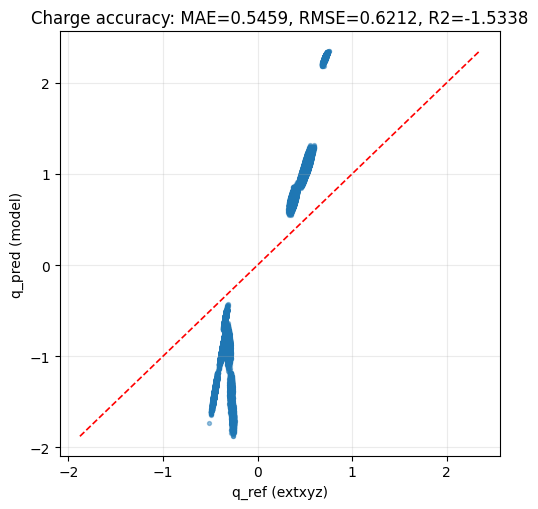

In [13]:
# 电荷准确度：q_ref vs q_pred（散点图 + MAE/RMSE/R^2）
import numpy as np
import matplotlib.pyplot as plt
from cace.data.atomic_data import AtomicData
from cace.tools import torch_geometric


def load_ref_charge_from_extxyz(path):
    q_blocks = []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            _ = f.readline()  # header
            q_now = []
            for _ in range(nat):
                parts = f.readline().split()
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                q_now.append(vals[6])
            q_blocks.append(np.asarray(q_now, dtype=np.float64))
    return np.concatenate(q_blocks, axis=0)


def predict_q_from_model(model, atoms_list, device="cpu"):
    model.eval()
    cutoff = float(model.models[0].representation.cutoff) if hasattr(model, "models") else float(model.representation.cutoff)

    ds = [AtomicData.from_atoms(a, cutoff=cutoff) for a in atoms_list]
    loader = torch_geometric.dataloader.DataLoader(ds, batch_size=4, shuffle=False, drop_last=False)

    q_all = []
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)
        if "q" not in out:
            raise KeyError(f"model output keys have no 'q': {list(out.keys())}")
        q_all.append(out["q"].detach().cpu().numpy().reshape(-1))
    return np.concatenate(q_all, axis=0)


q_ref = load_ref_charge_from_extxyz(str(DATA_PATH))
q_pred = predict_q_from_model(model, data, device="cpu")

assert q_ref.shape == q_pred.shape, f"shape mismatch: q_ref={q_ref.shape}, q_pred={q_pred.shape}"

mae = float(np.mean(np.abs(q_ref - q_pred)))
rmse = float(np.sqrt(np.mean((q_ref - q_pred) ** 2)))
ss_res = float(np.sum((q_ref - q_pred) ** 2))
ss_tot = float(np.sum((q_ref - np.mean(q_ref)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

print("q MAE :", mae)
print("q RMSE:", rmse)
print("q R^2 :", r2)
print("q_ref range :", float(q_ref.min()), float(q_ref.max()))
print("q_pred range:", float(q_pred.min()), float(q_pred.max()))

plt.figure(figsize=(5.2, 5.2))
plt.scatter(q_ref, q_pred, s=8, alpha=0.45)
mn = float(min(q_ref.min(), q_pred.min()))
mx = float(max(q_ref.max(), q_pred.max()))
plt.plot([mn, mx], [mn, mx], "r--", lw=1.2)
plt.xlabel("q_ref (extxyz)")
plt.ylabel("q_pred (model)")
plt.title(f"Charge accuracy: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()